# Version 2 Baseline Analysis

This notebook uses the installed package rather than duplicating its implementation. The original station problem and modeling methodology come from the 2024 project; all Version 2 equations, code, parameters, simulations, and plots are newly developed. All data are synthetic and illustrative.

In [1]:
from pathlib import Path

from IPython.display import Image, display

from metro_station_model import load_config, simulate
from metro_station_model.metrics import summary_metrics
from metro_station_model.plotting import plot_baseline

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
config = load_config(ROOT / "configs/baseline.yaml")
config.data["metadata"]

{'name': 'baseline',
 'description': 'Synthetic baseline with demand-controlled ventilation.',
 'data_status': 'synthetic_illustrative',
 'engineering_validation': False,
 'original_submission_data': False}

## Key assumptions

The station is a well-mixed ideal-gas air volume coupled to one effective structural thermal mass. Mechanical supply and exhaust have equal nominal volume flow; train piston exchange is bidirectional; leakage responds to pressure difference. CO₂ is only a ventilation-related state, not a complete indoor-air-quality measure.

In [2]:
result = simulate(config)
metrics = summary_metrics(result)
display(metrics)

{'scenario': 'baseline',
 'maximum_air_temperature_C': 29.932633083149142,
 'mean_air_temperature_C': np.float64(28.846764829156676),
 'maximum_structure_temperature_C': 25.94171670611246,
 'maximum_co2_ppm': 600.0,
 'mean_co2_ppm': np.float64(453.72673080299785),
 'maximum_absolute_pressure_difference_Pa': 1.9158530551212607,
 'mean_ventilation_airflow_m3_s': np.float64(38.96382157024345),
 'maximum_ventilation_airflow_m3_s': 45.181410963617,
 'total_fan_energy_proxy_kWh': 37.42030503725619,
 'total_passenger_heat_kWh': 10.55,
 'total_train_heat_kWh': 59.730932082731805,
 'time_above_27_C_s': 3412.5,
 'time_above_29_C_s': 1997.5,
 'time_above_1000_ppm_s': 0.0,
 'time_above_1200_ppm_s': 0.0,
 'minimum_air_mass_kg': 15094.005023253545,
 'maximum_air_mass_kg': 15292.379095470611,
 'minimum_air_changes_per_hour': 6.944444444444445,
 'mean_air_changes_per_hour': np.float64(10.823283769512066),
 'maximum_air_changes_per_hour': 12.550391934338053,
 'solver_function_evaluations': 34928,
 'sol

In [3]:
frame = result.frame
peak_temperature = frame.loc[frame["air_temperature_C"].idxmax()]
peak_co2 = frame.loc[frame["co2_ppm"].idxmax()]
display(
    peak_temperature[["time_min", "air_temperature_C", "passengers", "train_heat_W"]]
)
display(peak_co2[["time_min", "co2_ppm", "passengers", "ventilation_airflow_m3_s"]])

time_min                      36.5
air_temperature_C        29.932633
passengers                   248.0
train_heat_W         124433.595258
Name: 438, dtype: object

time_min                      0.0
co2_ppm                     600.0
passengers                    4.0
ventilation_airflow_m3_s     25.0
Name: 0, dtype: object

Passenger heat follows the interpolated occupancy schedule. Train heat combines direct heat during dwell with an exponentially decaying post-departure contribution. Their effects enter the same coupled air-energy balance; this notebook reports calculated association over time and does not claim measured causation.

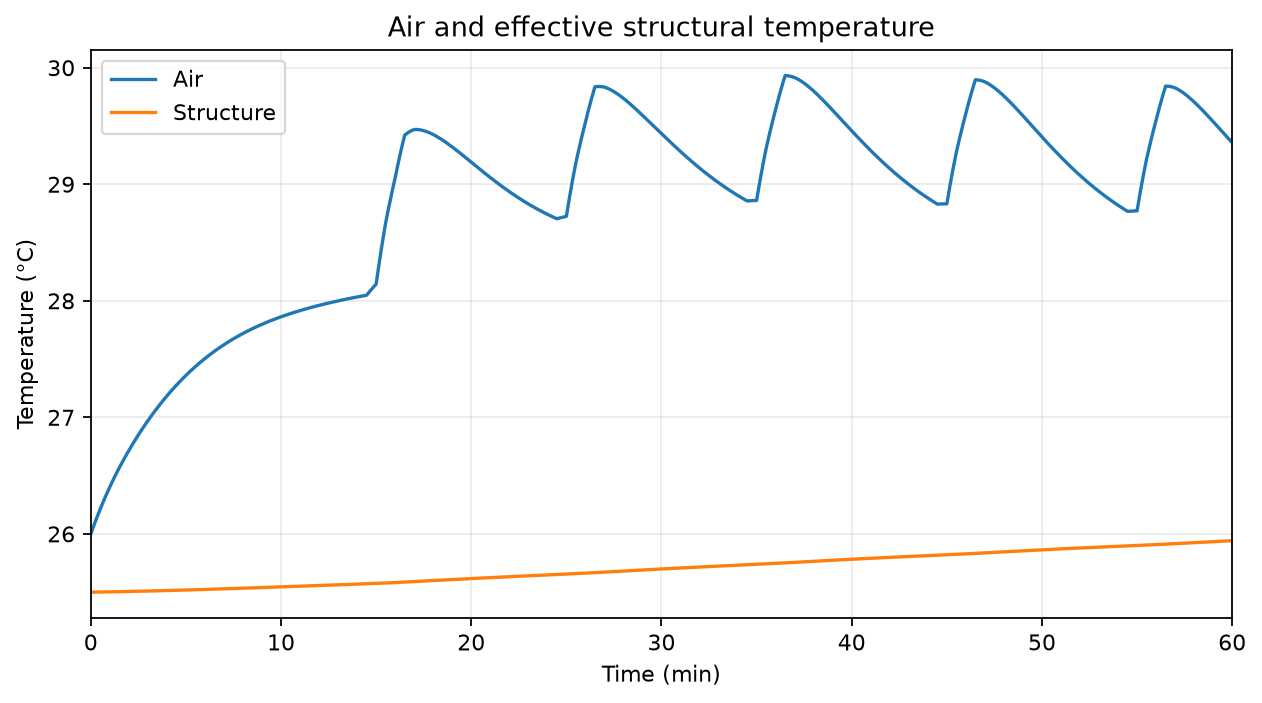

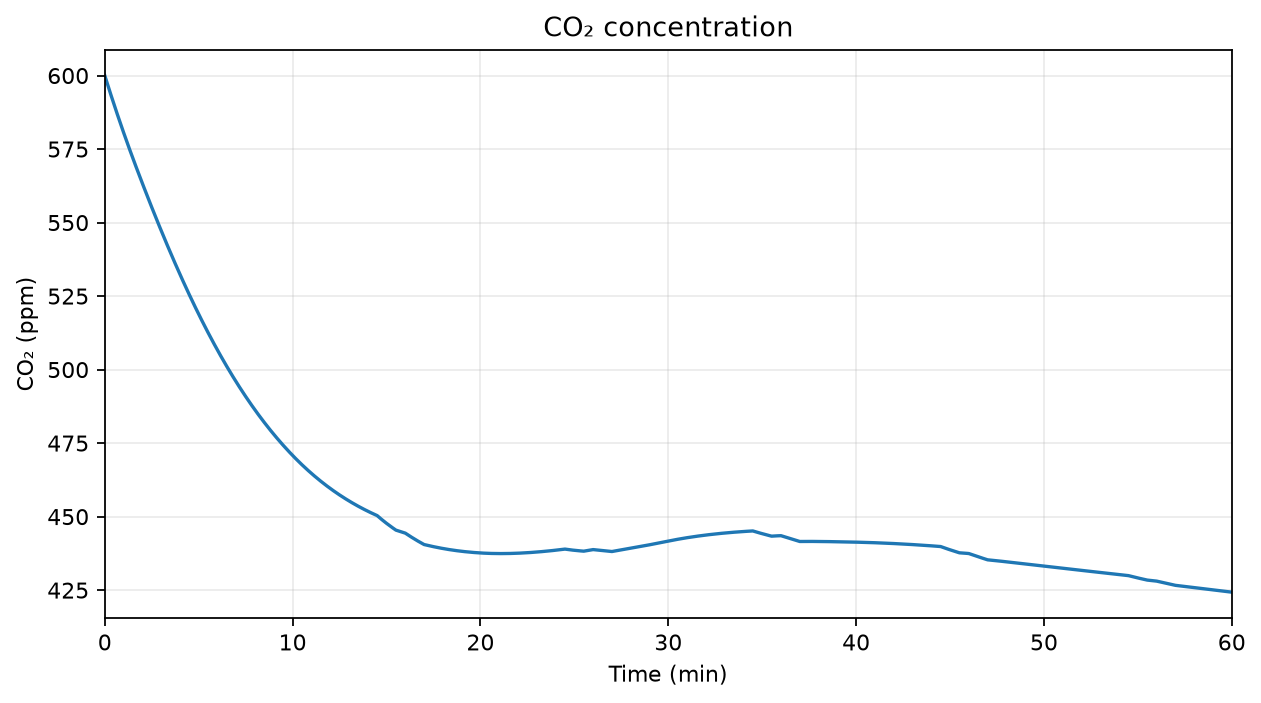

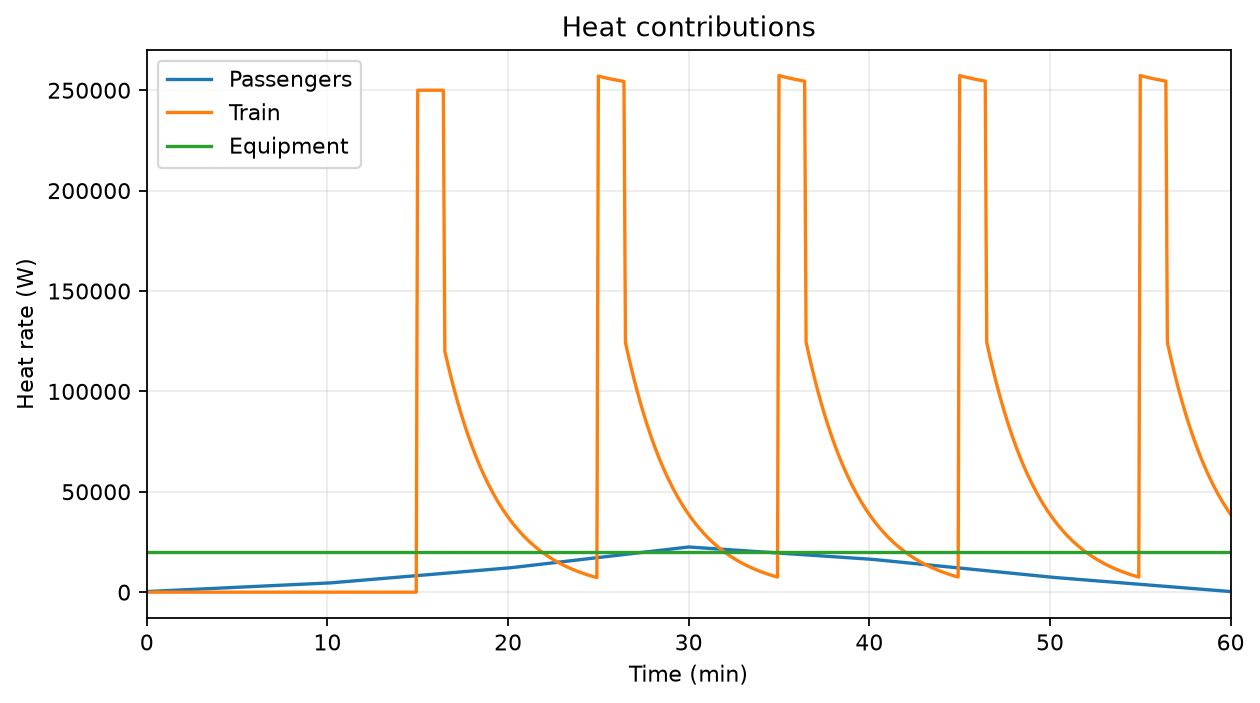

In [4]:
paths = plot_baseline(frame, ROOT / "results/baseline")
display(Image(filename=str(ROOT / "results/baseline/temperature.png")))
display(Image(filename=str(ROOT / "results/baseline/co2.png")))
display(Image(filename=str(ROOT / "results/baseline/heat_sources.png")))

The outputs are educational model results from synthetic inputs. They are not measurements, regulatory findings, or a basis for real HVAC, railway, smoke-control, or fire-safety decisions.